# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
#Type your code here
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Handling imbalance (opsional, kalau fraud data imbalance)
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Save model
import joblib



# **2. Memuat Dataset dari Hasil Clustering**
Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
# Gunakan dataset hasil clustering yang memiliki fitur Target
# Silakan gunakan dataset data_clustering jika tidak menerapkan Interpretasi Hasil Clustering [Advanced]
# Silakan gunakan dataset data_clustering_inverse jika menerapkan Interpretasi Hasil Clustering [Advanced]
# Lengkapi kode berikut
df = pd.read_csv("data_clustering_inverse.csv")


In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_outlier,LoginAttempts_flag,TransactionAmount_binned,CustomerAge_binned,TransactionAmount_binned_encoded,CustomerAge_binned_encoded,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,0,0,Low,Senior,1,2,2
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,0,0,High,Senior,0,2,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,0,0,Medium,Youth,2,3,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,0,0,Medium,Youth,2,3,0
4,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,0,0,Low,Youth,1,3,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243 entries, 0 to 2242
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   TransactionAmount                 2243 non-null   float64
 1   TransactionDate                   2243 non-null   object 
 2   TransactionType                   2243 non-null   object 
 3   Location                          2243 non-null   object 
 4   Channel                           2243 non-null   object 
 5   CustomerAge                       2243 non-null   float64
 6   CustomerOccupation                2243 non-null   object 
 7   TransactionDuration               2243 non-null   float64
 8   LoginAttempts                     2243 non-null   float64
 9   AccountBalance                    2243 non-null   float64
 10  PreviousTransactionDate           2243 non-null   object 
 11  TransactionAmount_outlier         2243 non-null   int64  
 12  LoginA

# **3. Data Splitting**
Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [4]:
# Menggunakan train_test_split() untuk melakukan pembagian dataset.
encoders = {}
for col in ['TransactionType', 'Channel']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Baru pilih fitur
selected_features = [
    'TransactionAmount',
    'CustomerAge',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance',
    'TransactionType',
    'Channel',
    'TransactionAmount_outlier',
    'TransactionAmount_binned_encoded',
    'CustomerAge_binned_encoded'
]

X = df[selected_features]
y = df['Target']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Fitur yang dipakai:", X.columns.tolist())
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Fitur yang dipakai: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionType', 'Channel', 'TransactionAmount_outlier', 'TransactionAmount_binned_encoded', 'CustomerAge_binned_encoded']
Train shape: (1794, 10) Test shape: (449, 10)
Jumlah data training: 1794
Jumlah data testing : 449


# **4. Membangun Model Klasifikasi**
Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Menggunakan algoritma klasifikasi yaitu Decision Tree.
2. Latih model menggunakan data yang sudah dipisah.

In [5]:
# Buatlah model klasifikasi menggunakan Decision Tree
# Inisialisasi model
dt_model = DecisionTreeClassifier(
    criterion='entropy',     # coba entropy
    max_depth=6,             # batasi kedalaman
    min_samples_split=20,    # minimum sampel utk split
    min_samples_leaf=10,     # minimum leaf
    class_weight='balanced', # atur balancing
    random_state=42
)

# Training
dt_model.fit(X_train, y_train)

# Prediksi
y_pred = dt_model.predict(X_test)

# Evaluasi
print("Akurasi :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Akurasi : 0.933184855233853

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        99
           1       0.97      0.93      0.95       120
           2       0.97      0.93      0.95       123
           3       0.91      0.93      0.92        69
           4       0.85      0.89      0.87        38

    accuracy                           0.93       449
   macro avg       0.92      0.93      0.92       449
weighted avg       0.94      0.93      0.93       449


Confusion Matrix:
 [[ 96   2   0   1   0]
 [  2 111   0   4   3]
 [  6   0 114   0   3]
 [  3   0   2  64   0]
 [  1   1   1   1  34]]


In [6]:
# Menyimpan Model
# import joblib
joblib.dump(dt_model, 'decision_tree_model.h5')

['decision_tree_model.h5']

# **5. Memenuhi Kriteria Skilled dan Advanced dalam Membangun Model Klasifikasi**



**Biarkan kosong jika tidak menerapkan kriteria skilled atau advanced**

In [7]:
# Melatih model menggunakan algoritma klasifikasi scikit-learn selain Decision Tree.
# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # jumlah pohon, bisa 100–300 (semakin besar semakin stabil)
    criterion='entropy',     # gunakan entropy seperti di Decision Tree
    max_depth=10,            # batasi kedalaman tiap pohon
    min_samples_split=10,    # minimum sampel untuk split
    min_samples_leaf=5,      # minimum sampel di setiap leaf
    class_weight='balanced', # penting untuk menyeimbangkan distribusi cluster
    random_state=42,
    n_jobs=-1                # gunakan semua core CPU agar training cepat
)

# Training model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf_model.predict(X_test)

Akurasi : 0.9532293986636972

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        99
           1       0.97      0.96      0.97       120
           2       0.99      0.93      0.96       123
           3       0.91      0.99      0.94        69
           4       0.88      0.95      0.91        38

    accuracy                           0.95       449
   macro avg       0.94      0.96      0.95       449
weighted avg       0.96      0.95      0.95       449


Confusion Matrix:
 [[ 94   2   0   2   1]
 [  0 115   0   3   2]
 [  4   0 115   2   2]
 [  1   0   0  68   0]
 [  0   1   1   0  36]]


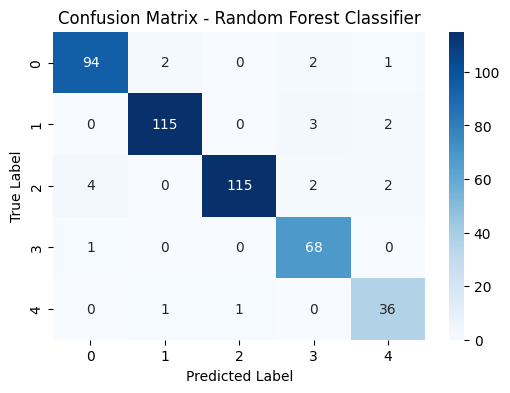

In [8]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat.

# Evaluasi performa model
print("Akurasi :", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
# Menyimpan Model Selain Decision Tree
# Model ini bisa lebih dari satu
# import joblib

joblib.dump(rf_model, 'explore_randomForest_classification.h5')

['explore_randomForest_classification.h5']

Hyperparameter Tuning Model

Pilih salah satu algoritma yang ingin Anda tuning

In [10]:
# Lakukan Hyperparameter Tuning dan Latih ulang.
# Lakukan dalam satu cell ini saja.

# Definisikan baseline parameter dari rf_model kamu
rf_base = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Tentukan grid parameter untuk tuning
param_grid = {
    'n_estimators': [150, 200, 250, 300],
    'max_depth': [8, 10, 12, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 5, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

# Inisialisasi model dasar
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Jalankan tuning
grid_search.fit(X_train, y_train)

# Ambil model dan parameter terbaik
best_rf = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Parameter terbaik hasil tuning: ")
print(best_params)

# Latih ulang model dengan parameter terbaik
best_rf.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Parameter terbaik hasil tuning: 
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 250}


RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=250, n_jobs=-1, random_state=42)

Akurasi Setelah Tuning: 0.9510

Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        99
           1       0.97      0.96      0.97       120
           2       0.98      0.93      0.96       123
           3       0.92      0.94      0.93        69
           4       0.90      0.95      0.92        38

    accuracy                           0.95       449
   macro avg       0.94      0.95      0.95       449
weighted avg       0.95      0.95      0.95       449



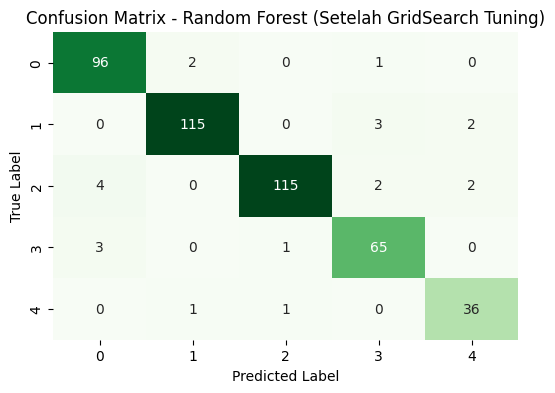

In [12]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada algoritma yang sudah dituning.
# Prediksi data uji
y_pred_best = best_rf.predict(X_test)

# Evaluasi performa model
acc = accuracy_score(y_test, y_pred_best)
print(f"Akurasi Setelah Tuning: {acc:.4f}\n")

print("Classification Report: ")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Confusion Matrix - Random Forest (Setelah GridSearch Tuning)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [13]:
# Menyimpan Model hasil tuning
# import joblib
joblib.dump(best_rf, 'tuning_classification.h5')

['tuning_classification.h5']

End of Code